In [596]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


In [597]:
demo = pd.read_csv('df_final_demo.csv')
experiment = pd.read_csv('df_final_experiment_clients.csv')
web_pt1 = pd.read_csv('df_final_web_data_pt_1.csv')
web_pt2 = pd.read_csv('df_final_web_data_pt_2.csv')

web = pd.concat([web_pt1, web_pt2], ignore_index=True)

##  DATASET INFORMATION

| Column               | Description                                             |
| -------------------- | ------------------------------------------------------- |
| **client_id**        | Unique identifier for each client                       |
| **variation**        | Indicates whether the client was part of the experiment |
| **visitor_id**       | Unique ID for each client–device combination            |
| **visit_id**         | Unique identifier for each web visit/session            |
| **process_step**     | Represents each step in the digital process             |
| **date_time**        | Timestamp of each web activity                          |
| **clnt_tenure_yr**   | Client tenure with Vanguard (in years)                  |
| **clnt_tenure_mnth** | Client tenure with Vanguard (in months)                 |
| **clnt_age**         | Age of the client                                       |
| **gendr**            | Gender of the client                                    |
| **num_accts**        | Number of accounts held by the client                   |
| **bal**              | Total balance across all client accounts                |
| **calls_6_mnth**     | Number of calls made by the client in the past 6 months |
| **logons_6_mnth**    | Number of platform logins in the past 6 months          |


In [598]:
demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [599]:
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [600]:
demo.isnull().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [601]:
demo[demo.isnull().any(axis=1)]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [602]:
demo.dropna(inplace=True)
#Decided to drop the rows with missing values since they were only 14/15 rows and they were not affecting the overall distribution of the data. 

In [603]:
demo.isnull().sum()

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
dtype: int64

In [604]:
demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.059400e+04,70594.000000,70594.000000,70594.000000,70594.000000,7.059400e+04,70594.000000,70594.000000
mean,5.005026e+06,12.053007,150.659999,46.442240,2.255532,1.474467e+05,3.382469,5.566720
std,2.877289e+06,6.871850,82.090264,15.591273,0.535000,3.015106e+05,2.236595,2.353296
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519543e+06,6.000000,82.000000,32.500000,2.000000,3.734660e+04,1.000000,4.000000
50%,5.016974e+06,11.000000,136.000000,47.000000,2.000000,6.333459e+04,3.000000,5.000000
75%,7.483074e+06,16.000000,192.000000,59.000000,2.000000,1.375461e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [605]:
demo["clnt_tenure_yr"]

0         6.0
1         7.0
2         5.0
3        16.0
4        12.0
         ... 
70604     4.0
70605    12.0
70606    16.0
70607    21.0
70608    21.0
Name: clnt_tenure_yr, Length: 70594, dtype: float64

In [606]:
print("Duplicate clinet_ids:", demo["client_id"].duplicated().sum())
print("/nGender values:")
print(demo["gendr"].value_counts(dropna=False))

Duplicate clinet_ids: 0
/nGender values:
gendr
U    24122
M    23724
F    22745
X        3
Name: count, dtype: int64


In [607]:
demo["gendr"].replace({"X": "U"}, inplace=True)

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/967283193.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  demo["gendr"].replace({"X": "U"}, inplace=True)


In [608]:
gendr_percentage=(demo["gendr"].value_counts()/len(demo["gendr"])*100).round(2)
gendr_percentage

gendr
U    34.17
M    33.61
F    32.22
Name: count, dtype: float64

In [609]:
demo['clnt_age'].describe()

count    70594.000000
mean        46.442240
std         15.591273
min         13.500000
25%         32.500000
50%         47.000000
75%         59.000000
max         96.000000
Name: clnt_age, dtype: float64

In [610]:
bins = [18, 35, 45, 55, 65, np.inf]
labels = ['18-34', '35-44', '45-54', '55-64', '65+']

demo["age_group"] = pd.cut(demo["clnt_age"], bins=bins, labels=labels, include_lowest=True)

In [611]:
grouped = (
    demo.groupby(["gendr", "age_group"])
    .size()
    .reset_index(name="count")
)

grouped

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/330943903.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demo.groupby(["gendr", "age_group"])


,gendr,age_group,count
0,F,18-34,4747
1,F,35-44,3953
2,F,45-54,5154
3,F,55-64,5400
4,F,65+,3433
5,M,18-34,5575
6,M,35-44,4267
7,M,45-54,5142
8,M,55-64,5189
9,M,65+,3475


In [612]:
bins = [0, 10, 20, 30, 40, 50, 60, 70]
labels = ["0–10", "11–20", "21–30", "31–40", "41–50", "51–60", "61–70"]

demo["year_range"] = pd.cut(
    demo["clnt_tenure_yr"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

g_loyalty = (
    demo.groupby(["year_range", "gendr"])
    .size()
    .reset_index(name="costumers")
)

g_loyalty

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/2591089112.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demo.groupby(["year_range", "gendr"])


,year_range,gendr,costumers
0,0–10,F,5934
1,0–10,M,6111
2,0–10,U,22350
3,11–20,F,12289
4,11–20,M,12923
5,11–20,U,1182
6,21–30,F,4064
7,21–30,M,4158
8,21–30,U,547
9,31–40,F,422


In [613]:
pivot_df = g_loyalty.pivot(
    index="year_range",
    columns="gendr",
    values="costumers"
)
pivot_df

gendr,F,M,U
year_range,,,
0–10,5934,6111,22350
11–20,12289,12923,1182
21–30,4064,4158,547
31–40,422,497,43
41–50,22,32,2
51–60,13,3,1
61–70,1,0,0


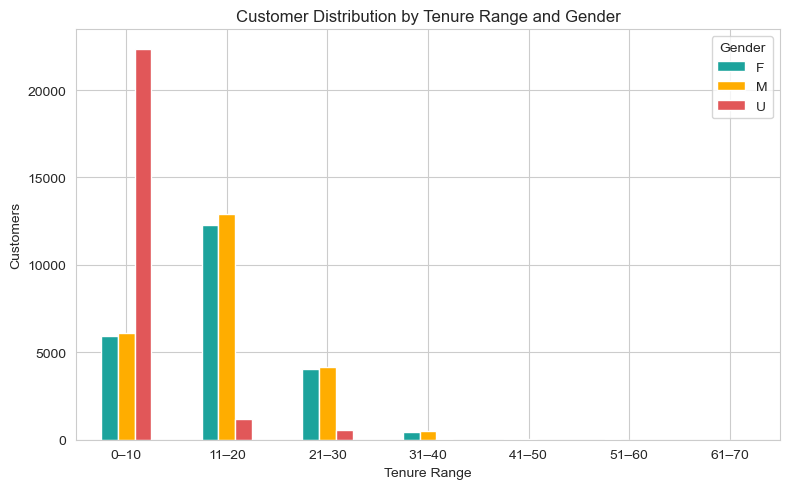

In [614]:
pivot_df.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1ca39c", "#ffad00", "#e15759"]  # green, yellow, red
)

plt.xlabel("Tenure Range")
plt.ylabel("Customers")
plt.title("Customer Distribution by Tenure Range and Gender")
plt.xticks(rotation=0)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

In [615]:
experiment.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [616]:
experiment.isnull().sum()

client_id        0
Variation    20109
dtype: int64

In [617]:
print("Shape:", experiment.shape)
print("Duplicate clinet_ids:", experiment["client_id"].duplicated().sum())
print("/nGroup sizes:")
print(experiment["Variation"].value_counts())

Shape: (70609, 2)
Duplicate clinet_ids: 0
/nGroup sizes:
Variation
Test       26968
Control    23532
Name: count, dtype: int64


In [618]:
demo_ids = set(demo["client_id"])
exp_ids = set(experiment["client_id"])

print(f"Clients in demo only:        {len(demo_ids - exp_ids)}")
print(f"Clients in experiment only:  {len(exp_ids - demo_ids)}")
print(f"Clients in both:             {len(demo_ids & exp_ids)}")

Clients in demo only:        0
Clients in experiment only:  15
Clients in both:             70594


In [619]:
web.head(10)
#think about clients that go back and fort between steps, and how to handle that. Maybe we can just look at the first step for each client, or the last step, or the most common step. We can also look at the time spent on each step, and see if there are any patterns there.

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
5,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:17:15
6,9988021,580560515_7732621733,781255054_21935453173_531117,step_1,2017-04-17 15:17:01
7,9988021,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17 15:16:22
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05
9,8320017,39393514_33118319366,960651974_70596002104_312201,step_3,2017-04-05 13:09:43


In [620]:
web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 755405 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     755405 non-null  int64 
 1   visitor_id    755405 non-null  object
 2   visit_id      755405 non-null  object
 3   process_step  755405 non-null  object
 4   date_time     755405 non-null  object
dtypes: int64(1), object(4)
memory usage: 28.8+ MB


In [621]:
print("Duplicate client_ids:", web["client_id"].duplicated().sum())

Duplicate client_ids: 635248


In [622]:
web.groupby("client_id").size().describe()

count    120157.000000
mean          6.286816
std           3.986973
min           1.000000
25%           5.000000
50%           5.000000
75%           7.000000
max         111.000000
dtype: float64

In [623]:
web["date_time"] = pd.to_datetime(web["date_time"])
print("Date range:", web["date_time"].min(), "to", web["date_time"].max())
print("\nProcess steps:")
print(web["process_step"].value_counts()) #How many times each step in the digital journey occurs

Date range: 2017-03-15 00:03:03 to 2017-06-20 23:59:57

Process steps:
process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64


## 🧩 Data Hierarchy

```
client (client_id)
└── visitor (visitor_id) — one per device the client uses
    └── visit (visit_id) — one per session/web visit
        └── process_step — one action within that session
```

---

## 📌 Key Notes

- A single **client** can:
  - Use **multiple devices** → multiple `visitor_id`
  - Have **multiple visits per device** → multiple `visit_id`
  - Perform **multiple steps per visit** → multiple rows per `visit_id`

---

## 🎯 Why This Matters

Understanding this hierarchy determines how you measure and analyze behavior:

- **Completion rate**
  - Should it be measured per **client**, **visitor**, or **visit**?

- **Time per step**
  - Must be calculated **within the same visit/session**

- **Error rate**
  - Example: users going **backwards within a visit**

- **Avoid incorrect counting**
  - Counting rows ≠ counting visits or clients

```
client (client_id)
└── visitor (visitor_id) — one per device the client uses
    └── visit (visit_id) — one per session/web visit
        └── process_step — one action within that session
```

In [624]:
print("Unique clients in web data: ", web["client_id"].nunique())
print("Unique visitors: ", web["visitor_id"].nunique())
print("Unique visits (sessions): ", web["visit_id"].nunique())
print("Total rows (step events): ", len(web))

Unique clients in web data:  120157
Unique visitors:  130236
Unique visits (sessions):  158095
Total rows (step events):  755405


## 🔗 How the Datasets Connect

All three datasets link through `client_id`:

```
demo (client profile)
        └── client_id → Full picture per client
experiment (Test/Ctrl)
        └── client_id → Full picture per client
web (activity logs)
        └── client_id → Web behavior per client
```

---

## 📌 Key Idea

- `client_id` is the **common key** across all datasets  
- It allows you to **merge data** and build a **complete view of each client**

---

## ⚠️ Before Merging — Important Check

Always verify whether all clients appear in all datasets:

- Are there clients in **experiment** but not in **web**?
- Are there clients in **web** but not in **experiment**?
- Do all clients exist in **demo**?

---

In [625]:
web_ids = set(web["client_id"])

print(f"Clients in demo:        {len(demo_ids):,}")
print(f"Clients in experiment:  {len(exp_ids):,}")
print(f"Clients in web:         {len(web_ids):,}")

print()

print(f"In all three:                {len(demo_ids & exp_ids & web_ids):,}")
print(f"In experiment but NOT in web:{len(exp_ids - web_ids):,}")
print(f"In web but NOT in experiment:{len(web_ids - exp_ids):,}")

Clients in demo:        70,594
Clients in experiment:  70,609
Clients in web:         120,157

In all three:                70,594
In experiment but NOT in web:0
In web but NOT in experiment:49,548


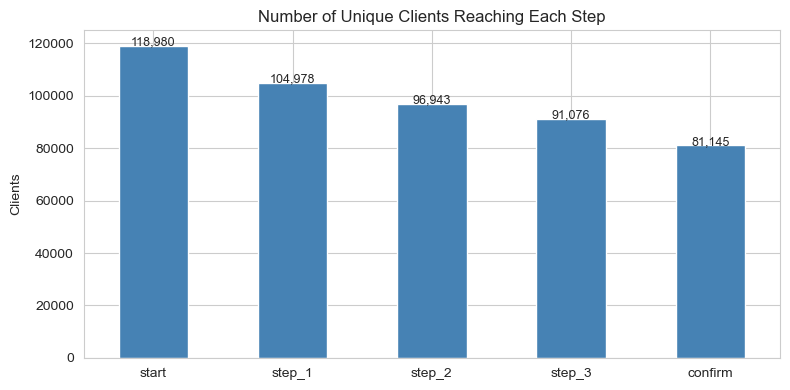

In [626]:
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

clients_per_step = (
    web.groupby("process_step")["client_id"]
    .nunique()
    .reindex(step_order)
)

fig, ax = plt.subplots(figsize=(8, 4))

clients_per_step.plot(
    kind="bar",
    ax=ax,
    color="steelblue",
    edgecolor="white"
)

ax.set_title("Number of Unique Clients Reaching Each Step")
ax.set_ylabel("Clients")
ax.set_xlabel("")
ax.set_xticklabels(step_order, rotation=0)

for i, v in enumerate(clients_per_step.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

#Important Funnel, Customer start dropping throught the process.

## What's Next?

You now have a foundation. From here, your next steps are:

1. **Clean the data** — handle nulls, duplicates, type inconsistencies  
2. **Merge the datasets** — decide on the right merge strategy  
3. **Compute your KPIs** — completion rate, time per step, error rate (per group)  
4. **Compare Test vs. Control** — are there real differences?  
5. **Run hypothesis tests** — are those differences statistically significant?  

In [627]:
merged = demo.merge(experiment, on="client_id", how="inner")

merged.columns = merged.columns.str.strip().str.lower().str.replace(" ", "_")

merged.head()



,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,year_range,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,55-64,0–10,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,55-64,0–10,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,18-34,0–10,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,45-54,11–20,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,18-34,11–20,Control


In [628]:
grouped = merged.groupby("variation").agg({
    "clnt_age": ["mean", "median"],
    "num_accts": ["mean"],
    "clnt_tenure_yr": ["mean"],
    "gendr": lambda x: x.value_counts().to_dict()
}).round(2)
grouped

clnt_age        num_accts clnt_tenure_yr  \
              mean median      mean           mean   
variation                                            
Control      47.50   48.5      2.26          12.09   
Test         47.16   47.5      2.25          11.98   

                                       gendr  
                                    <lambda>  
variation                                     
Control    {'U': 8014, 'M': 7970, 'F': 7542}  
Test       {'U': 9268, 'M': 8977, 'F': 8716}

In [629]:
counts = merged["variation"].value_counts()
print(counts)

variation
Test       26961
Control    23526
Name: count, dtype: int64


In [630]:
variance_percentage = (
    merged["variation"]
    .value_counts(normalize=True) * 100
).round(2)

variance_percentage

variation
Test       53.4
Control    46.6
Name: proportion, dtype: float64

In [631]:
merged_1 = merged.merge(web, on="client_id", how="inner")

merged_1.columns = (
    merged_1.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Drop rows inplace using index filtering
merged_1.drop(
    index=merged_1[merged_1["gendr"] == "U"].index,
    inplace=True
)

merged_1.drop(
    index=merged_1[merged_1["age_group"] == "0-17"].index,
    inplace=True
)

merged_1.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,year_range,variation,visitor_id,visit_id,process_step,date_time
22,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,45-54,11–20,Test,391202328_71710993352,71954691_44810191073_495385,start,2017-04-06 19:03:46
23,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,18-34,11–20,Control,432077852_35036160885,942996157_39527225999_589383,start,2017-06-14 14:22:31
36,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,55-64,21–30,Test,56607555_75044897582,247503697_11679931698_453228,confirm,2017-04-06 10:48:22
37,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,55-64,21–30,Test,56607555_75044897582,247503697_11679931698_453228,step_3,2017-04-06 10:45:09
38,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,55-64,21–30,Test,56607555_75044897582,247503697_11679931698_453228,step_2,2017-04-06 10:41:56


In [632]:
merged_1.drop(columns=["clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "bal","num_accts"], inplace=True)
merged_1.head()

,client_id,gendr,calls_6_mnth,logons_6_mnth,age_group,year_range,variation,visitor_id,visit_id,process_step,date_time
22,1562045,M,3.0,6.0,45-54,11–20,Test,391202328_71710993352,71954691_44810191073_495385,start,2017-04-06 19:03:46
23,5126305,F,0.0,3.0,18-34,11–20,Control,432077852_35036160885,942996157_39527225999_589383,start,2017-06-14 14:22:31
36,388801,M,1.0,4.0,55-64,21–30,Test,56607555_75044897582,247503697_11679931698_453228,confirm,2017-04-06 10:48:22
37,388801,M,1.0,4.0,55-64,21–30,Test,56607555_75044897582,247503697_11679931698_453228,step_3,2017-04-06 10:45:09
38,388801,M,1.0,4.0,55-64,21–30,Test,56607555_75044897582,247503697_11679931698_453228,step_2,2017-04-06 10:41:56


In [633]:
merged_1["date_time"].describe()

count                           298082
mean     2017-04-20 10:20:30.785746432
min                2017-03-15 00:03:03
25%         2017-04-04 18:50:39.500000
50%                2017-04-12 15:34:18
75%                2017-05-01 14:28:58
max                2017-06-20 23:57:06
Name: date_time, dtype: object

In [634]:
merged_1["variation"].value_counts()


variation
Test       118255
Control     94048
Name: count, dtype: int64

In [635]:
# Check if each visit belongs to only one "variation"
merged_1.groupby("visit_id")["variation"].nunique().max()
# 2 means that there are some visits that are related to each group

2

In [636]:
# Identify problematic visits
bad_visits = (
    merged_1.groupby("visit_id")["variation"]
    .nunique()
    .reset_index()
)
bad_visits = bad_visits[bad_visits["variation"] > 1]
print(len(bad_visits))

57


In [637]:
# Inspect the "bad visits"
merged_1[merged_1["visit_id"].isin(bad_visits)].sort_values("visit_id")

,client_id,gendr,calls_6_mnth,logons_6_mnth,age_group,year_range,variation,visitor_id,visit_id,process_step,date_time


In [670]:
bad_clients = (
    merged_1.groupby("client_id")["variation"]
    .nunique()
)
bad_clients = bad_clients[bad_clients > 1].index

clean_df = merged_1[~merged_1["client_id"].isin(bad_clients)].copy()

In [639]:
# Ensure datetime
clean_df["date_time"] = pd.to_datetime(clean_df["date_time"])

# Sort correctly
clean_df = clean_df.sort_values(["client_id", "date_time"]).copy()

# Time to next step for each client
clean_df["next_time"] = clean_df.groupby("client_id")["date_time"].shift(-1)

clean_df["step_gap_sec"] = (
    clean_df["next_time"] - clean_df["date_time"]
).dt.total_seconds()

# Find clients with any gap > 1 hour
clients_over_1h = clean_df.loc[
    clean_df["step_gap_sec"] > 3600,
    "client_id"
].unique()

# Drop those clients entirely
clean_df = clean_df[
    ~clean_df["client_id"].isin(clients_over_1h)
]

clean_df.head()

,client_id,gendr,calls_6_mnth,logons_6_mnth,age_group,year_range,variation,visitor_id,visit_id,process_step,date_time,next_time,step_gap_sec
381112,169,M,4.0,4.0,45-54,21–30,NaN,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36,2017-04-12 20:19:45,9.0
381111,169,M,4.0,4.0,45-54,21–30,NaN,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45,2017-04-12 20:20:31,46.0
381110,169,M,4.0,4.0,45-54,21–30,NaN,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31,2017-04-12 20:22:05,94.0
381109,169,M,4.0,4.0,45-54,21–30,NaN,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05,2017-04-12 20:23:09,64.0
381108,169,M,4.0,4.0,45-54,21–30,NaN,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09,NaT,NaN


In [640]:
clean_df.value_counts()

client_id  gendr  calls_6_mnth  logons_6_mnth  age_group  year_range  variation  visitor_id             visit_id                      process_step  date_time            next_time            step_gap_sec
7733877    F      3.0           6.0            45-54      0–10        Control    219522655_85340908938  308874104_3998249411_902973   start         2017-05-02 10:36:55  2017-05-02 10:36:55  0.0             15
                                                                                                                                                    2017-05-02 10:41:48  2017-05-02 10:41:48  0.0             15
1952790    F      5.0           8.0            55-64      21–30       Control    780189529_68744403580  961878360_85895454962_607105  start         2017-05-02 10:23:39  2017-05-02 10:23:39  0.0             15
                                                                                                                                                    2017-05-02 10:53:01  2

In [641]:
pivot_steps = clean_df.pivot_table(
    index="client_id",
    columns="process_step",
    aggfunc="size",
    fill_value=0
)
pivot_steps

process_step,confirm,start,step_1,step_2,step_3
client_id,,,,,
169,1,1,1,1,1
647,1,1,1,1,1
722,1,2,3,2,1
934,0,4,0,0,0
1028,0,1,5,2,1
...,...,...,...,...,...
9998921,0,1,0,0,0
9999009,1,1,1,1,1
9999626,0,1,1,0,0


In [642]:
step_order = {
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

In [643]:
import numpy as np

# sort events
clean_df = clean_df.sort_values(["client_id", "date_time"]).copy()

# step column
clean_df["step_full"] = clean_df["process_step"].fillna("start")

# valid path order
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]
step_map = {step: i for i, step in enumerate(step_order)}

# numeric step
clean_df["step_num"] = clean_df["step_full"].map(step_map)

# next step for same client
clean_df["next_step"] = clean_df.groupby("client_id")["step_full"].shift(-1)
clean_df["next_step_num"] = clean_df.groupby("client_id")["step_num"].shift(-1)

# step difference
clean_df["step_diff"] = clean_df["next_step_num"] - clean_df["step_num"]

# --------------------------------------------------
# VALID if:
# +1 = normal forward
#  0 = repeated same step (allowed)
# --------------------------------------------------
clean_df["is_error"] = np.where(
    clean_df["next_step_num"].isna(),
    np.nan,
    ~clean_df["step_diff"].isin([0, 1])
)

# error types
clean_df["error_type"] = "valid"
clean_df.loc[clean_df["step_diff"] < 0, "error_type"] = "backward"
clean_df.loc[clean_df["step_diff"] > 1, "error_type"] = "skip_forward"
clean_df.loc[clean_df["next_step_num"].isna(), "error_type"] = None

In [644]:
error_rate = clean_df["is_error"].mean() * 100
print(f"Overall error rate: {error_rate:.2f}%")

Overall error rate: 9.76%


In [645]:
error_by_variation = (
    clean_df.groupby("variation")["is_error"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="error_rate_pct")
)

print(error_by_variation)

  variation  error_rate_pct
0   Control            8.36
1      Test           10.76


In [646]:
error_by_step = (
    clean_df.groupby(["step_full", "variation"])["is_error"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="error_rate_pct")
)

pivot_error = error_by_step.pivot(
    index="step_full",
    columns="variation",
    values="error_rate_pct"
).reindex(["start", "step_1", "step_2", "step_3", "confirm"])

print(pivot_error)

variation  Control   Test
step_full                
start         0.92   1.47
step_1        8.73  16.99
step_2        7.56  13.20
step_3       17.21  15.61
confirm      39.12   9.07


In [647]:
error_by_age = (
    clean_df.groupby(["age_group", "variation"])["is_error"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name="error_rate_pct")
)


/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/2395335628.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_df.groupby(["age_group", "variation"])["is_error"]


In [648]:
pivot_df = (
    error_by_age.pivot(
        index="age_group",
        columns="variation",
        values="error_rate_pct"
    )
    .reindex(["18-34", "35-44", "45-54", "55-64", "65+"])
    .round(2)
)

print(pivot_df)

variation  Control   Test
age_group                
18-34         7.70   8.65
35-44         7.41   9.29
45-54         8.00  11.35
55-64         9.20  12.44
65+           9.70  12.21


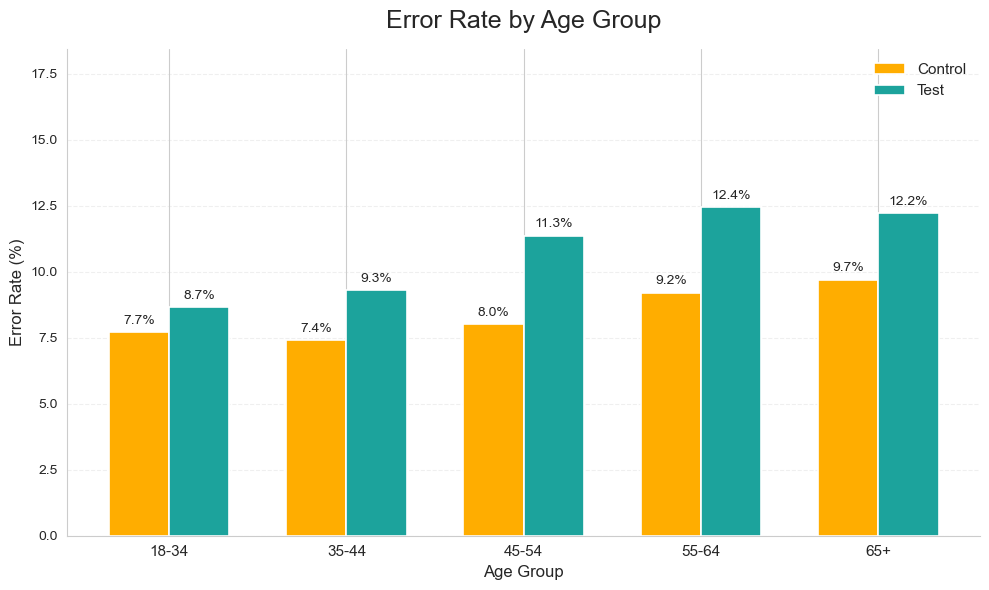

In [649]:

plot_df = pivot_df.reindex(["18-34", "35-44", "45-54", "55-64", "65+"])

x = np.arange(len(plot_df.index))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

bars1 = ax.bar(
    x - width/2,
    plot_df["Control"],
    width,
    label="Control",
    color="#ffad00",
    edgecolor="white",
    linewidth=1.2
)

bars2 = ax.bar(
    x + width/2,
    plot_df["Test"],
    width,
    label="Test",
    color="#1ca39c",
    edgecolor="white",
    linewidth=1.2
)

# Labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.1f}%",
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10
        )

# Formatting
ax.set_title("Error Rate by Age Group", fontsize=18, pad=15)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Error Rate (%)", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize=11)

ax.set_ylim(0, max(plot_df.max()) + 6)

# Clean grid
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Remove clutter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

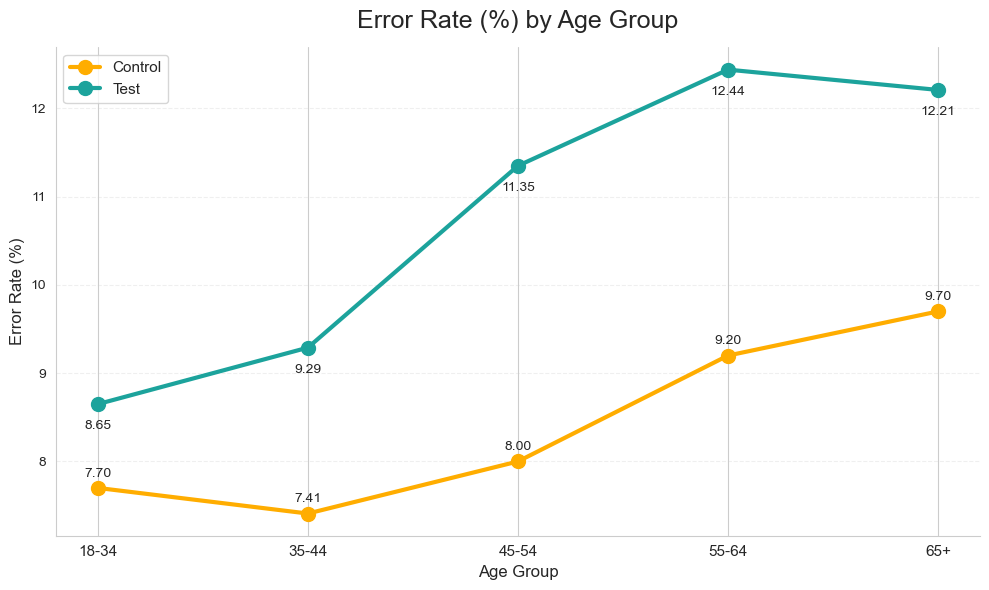

In [650]:


# Optional: remove 0-17
plot_df = pivot_df.reindex(["18-34", "35-44", "45-54", "55-64", "65+"])

x = np.arange(len(plot_df.index))

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

ax.plot(
    x,
    plot_df["Control"],
    marker="o",
    markersize=10,
    linewidth=3,
    label="Control",
    color="#ffad00"
)

ax.plot(
    x,
    plot_df["Test"],
    marker="o",
    markersize=10,
    linewidth=3,
    label="Test",
    color="#1ca39c"
)

# Labels on points
for i, y in enumerate(plot_df["Control"]):
    ax.annotate(f"{y:.2f}", (x[i], y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=10)

for i, y in enumerate(plot_df["Test"]):
    ax.annotate(f"{y:.2f}", (x[i], y), textcoords="offset points", xytext=(0, -18), ha="center", fontsize=10)

# Formatting
ax.set_title("Error Rate (%) by Age Group", fontsize=18, pad=14)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Error Rate (%)", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize=11)

ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

In [651]:

# Keep only errors
transition_errors = clean_df[
    clean_df["is_error"] == True
].copy()

# Create transition label
transition_errors["transition"] = (
    transition_errors["step_full"] + " → " + transition_errors["next_step"]
)

# Count transitions
error_transitions = (
    transition_errors.groupby("transition")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# Percentage of all errors
total_errors = error_transitions["count"].sum()

error_transitions["pct"] = (
    error_transitions["count"] / total_errors * 100
).round(2)

print(error_transitions)

          transition  count    pct
8     step_1 → start   4977  34.45
15   step_3 → step_2   2348  16.25
12   step_2 → step_1   2303  15.94
13    step_3 → start   1725  11.94
11    step_2 → start   1210   8.38
14   step_3 → step_1    533   3.69
0    confirm → start    474   3.28
6     start → step_3    281   1.95
5     start → step_2    273   1.89
3   confirm → step_3    114   0.79
1   confirm → step_1     83   0.57
9    step_1 → step_3     55   0.38
10  step_2 → confirm     38   0.26
4    start → confirm     24   0.17
7   step_1 → confirm      5   0.03
2   confirm → step_2      4   0.03


In [652]:
# Keep only errors
transition_errors = clean_df[
    clean_df["is_error"] == True
].copy()

# Create transition label
transition_errors["transition"] = (
    transition_errors["step_full"] + " → " + transition_errors["next_step"]
)

# Count errors by transition and variation
error_var = (
    transition_errors.groupby(["transition", "variation"])
    .size()
    .reset_index(name="count")
)

# Convert to %
error_var["pct"] = (
    error_var.groupby("variation")["count"]
    .transform(lambda x: round(x / x.sum() * 100, 2))
)

# Pivot for chart
pivot_var = error_var.pivot(
    index="transition",
    columns="variation",
    values="pct"
).fillna(0)

# Sort by total errors
pivot_var["total"] = pivot_var.sum(axis=1)
pivot_var = pivot_var.sort_values("total", ascending=True).drop(columns="total")

print(pivot_var)

variation         Control   Test
transition                      
confirm → step_2     0.00   0.02
step_1 → confirm     0.03   0.03
start → confirm      0.08   0.20
step_2 → confirm     0.64   0.08
step_1 → step_3      0.49   0.24
confirm → step_1     1.16   0.20
confirm → step_3     1.60   0.25
start → step_2       1.52   2.16
start → step_3       1.80   2.01
confirm → start      6.12   1.45
step_3 → step_1      8.00   1.38
step_2 → start       7.13   8.83
step_3 → start      11.11  12.62
step_2 → step_1     13.04  17.72
step_3 → step_2     22.61  12.78
step_1 → start      24.67  40.03


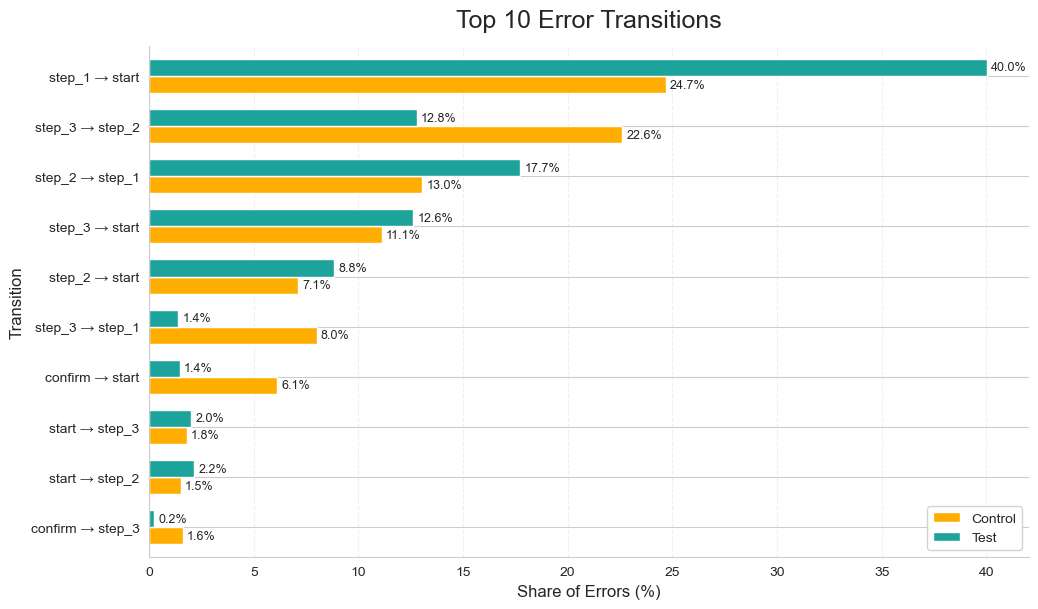

In [653]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep only error rows
transition_errors = clean_df[clean_df["is_error"] == True].copy()

# Remove repeated same-step loops
transition_errors = transition_errors[
    transition_errors["step_full"] != transition_errors["next_step"]
].copy()

# Create transition label
transition_errors["transition"] = (
    transition_errors["step_full"] + " → " + transition_errors["next_step"]
)

# Count by transition + variation
error_var = (
    transition_errors.groupby(["transition", "variation"])
    .size()
    .reset_index(name="count")
)

# Convert to % inside each variation
error_var["pct"] = (
    error_var.groupby("variation")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

# Pivot
pivot_var = error_var.pivot(
    index="transition",
    columns="variation",
    values="pct"
).fillna(0)

# Keep Top 10
pivot_var["total"] = pivot_var.sum(axis=1)

pivot_var = (
    pivot_var.sort_values("total", ascending=False)
    .head(10)
    .drop(columns="total")
    .round(2)
)

# Plot
fig, ax = plt.subplots(figsize=(10.5, 6.2), facecolor="white")
ax.set_facecolor("white")

pivot_var.iloc[::-1].plot(
    kind="barh",
    ax=ax,
    color=["#ffad00", "#1ca39c"],
    width=0.68
)

# Labels on bars (show ALL % values)
for container in ax.containers:
    labels = [f"{v:.1f}%" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

# Styling
ax.set_title("Top 10 Error Transitions", fontsize=18, pad=14)
ax.set_xlabel("Share of Errors (%)", fontsize=12)
ax.set_ylabel("Transition", fontsize=12)

ax.xaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Framed legend
ax.legend(
    title=None,
    loc="lower right",
    frameon=True,
    fancybox=True,
    framealpha=1,
    edgecolor="lightgray"
)

plt.tight_layout()
plt.show()

In [654]:

# Average calls + logins by age group
usage_age = (
    clean_df.groupby("age_group")[["calls_6_mnth", "logons_6_mnth"]]
    .mean()
    .round(1)
    .reset_index()
)

print(usage_age)

  age_group  calls_6_mnth  logons_6_mnth
0     18-34           3.3            5.3
1     35-44           3.0            5.1
2     45-54           3.1            5.2
3     55-64           3.3            5.5
4       65+           3.3            5.9


/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/2400732689.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_df.groupby("age_group")[["calls_6_mnth", "logons_6_mnth"]]


In [655]:
merged_calls = clean_df.copy()
merged_calls.columns = (
    merged_calls.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Keep one row per client for demographic/account-level variables
client_level = merged_calls[
    ["client_id", "age_group", "gendr", "variation", "calls_6_mnth", "logons_6_mnth"]
].drop_duplicates()

# Remove unknown gender and youngest group if needed
client_level = client_level[
    client_level["gendr"].notna() &
    (client_level["gendr"] != "U") &
    (client_level["age_group"] != "0-17")
]

calls_logins_summary = (
    client_level.groupby(["age_group", "gendr", "variation"])[["calls_6_mnth", "logons_6_mnth"]]
    .mean()
    .reset_index()
    .round(1)
)

print(calls_logins_summary)

   age_group gendr variation  calls_6_mnth  logons_6_mnth
0      18-34     F   Control           2.7            5.7
1      18-34     F      Test           2.5            5.5
2      18-34     M   Control           3.4            6.4
3      18-34     M      Test           3.2            6.3
4      35-44     F   Control           2.4            5.4
5      35-44     F      Test           2.4            5.4
6      35-44     M   Control           2.9            5.9
7      35-44     M      Test           3.0            6.0
8      45-54     F   Control           2.4            5.5
9      45-54     F      Test           2.5            5.6
10     45-54     M   Control           3.1            6.2
11     45-54     M      Test           3.0            6.1
12     55-64     F   Control           2.7            5.7
13     55-64     F      Test           2.7            5.8
14     55-64     M   Control           3.3            6.3
15     55-64     M      Test           3.3            6.3
16       65+  

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/1578583476.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  client_level.groupby(["age_group", "gendr", "variation"])[["calls_6_mnth", "logons_6_mnth"]]


In [656]:
# Number of clients per accounts & variation
accounts_group = (
    merged.groupby(["variation", "num_accts"])["client_id"]
    .nunique()
    .reset_index(name="num_clients")
    .sort_values("num_accts")
)
accounts_group

,variation,num_accts,num_clients
6,Test,1.0,1
0,Control,2.0,18410
7,Test,2.0,21310
1,Control,3.0,4251
8,Test,3.0,4696
2,Control,4.0,745
9,Test,4.0,840
3,Control,5.0,108
10,Test,5.0,97
4,Control,6.0,10


In [660]:
# Check clients with > 2 accounts
filtered = accounts_group[accounts_group["num_accts"] > 2]
filtered

,variation,num_accts,num_clients
1,Control,3.0,4251
8,Test,3.0,4696
2,Control,4.0,745
9,Test,4.0,840
3,Control,5.0,108
10,Test,5.0,97
4,Control,6.0,10
11,Test,6.0,13
5,Control,7.0,2
12,Test,7.0,4


In [661]:
general = merged[merged["num_accts"] == 2]
result = (
    general.groupby("variation")["client_id"]
    .nunique()
    .reset_index(name="num_clients")
)
result
# Total 36,590 clients with 2 accounts in both groups

,variation,num_clients
0,Control,18410
1,Test,21310


In [668]:
import pandas as pd

# -----------------------------------
# Client-level error flag
# -----------------------------------
error_client = (
    clean_df.groupby("client_id")
    .agg(
        had_error=("is_error", lambda x: x.fillna(False).any())
    )
    .reset_index()
)

# -----------------------------------
# Merge demographics + variation
# -----------------------------------
error_accounts = error_client.merge(
    merged[
        ["client_id", "variation", "age_group", "num_accts"]
    ].drop_duplicates(),
    on="client_id",
    how="left"
)

# Remove youngest group
error_accounts = error_accounts[
    error_accounts["age_group"] != "0-17"
]

# -----------------------------------
# SIMPLE PIVOTS (one per variation)
# -----------------------------------
for var in ["Control", "Test"]:

    temp = error_accounts[
        error_accounts["variation"] == var
    ]

    pivot = pd.pivot_table(
        temp,
        index="age_group",
        columns="num_accts",
        values="had_error",
        aggfunc="mean"
    ) * 100

    pivot = pivot.round(1)

    print(f"\n===== {var} : Error Rate (%) =====")
    print(pivot)

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/2204352095.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  had_error=("is_error", lambda x: x.fillna(False).any())



===== Control : Error Rate (%) =====
num_accts   2.0   3.0   4.0   5.0    6.0
age_group                               
18-34      22.5  19.4  24.1   0.0    NaN
35-44      19.1  20.6  31.7   0.0    0.0
45-54      21.4  16.7  25.0  25.0  100.0
55-64      23.7  25.2  13.3   0.0    0.0
65+        21.5  26.4  30.8  16.7    0.0

===== Test : Error Rate (%) =====
num_accts   2.0   3.0   4.0   5.0    6.0   7.0
age_group                                     
18-34      25.8  22.7  27.8  16.7    0.0   0.0
35-44      27.6  24.4  25.3   8.3    NaN  50.0
45-54      31.3  26.0  17.2  28.6    NaN   NaN
55-64      32.1  31.4  26.1  16.7   25.0   NaN
65+        31.3  31.5  20.3  33.3  100.0   NaN


/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/2204352095.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(
/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/2204352095.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/2978954260.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(
/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/2978954260.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


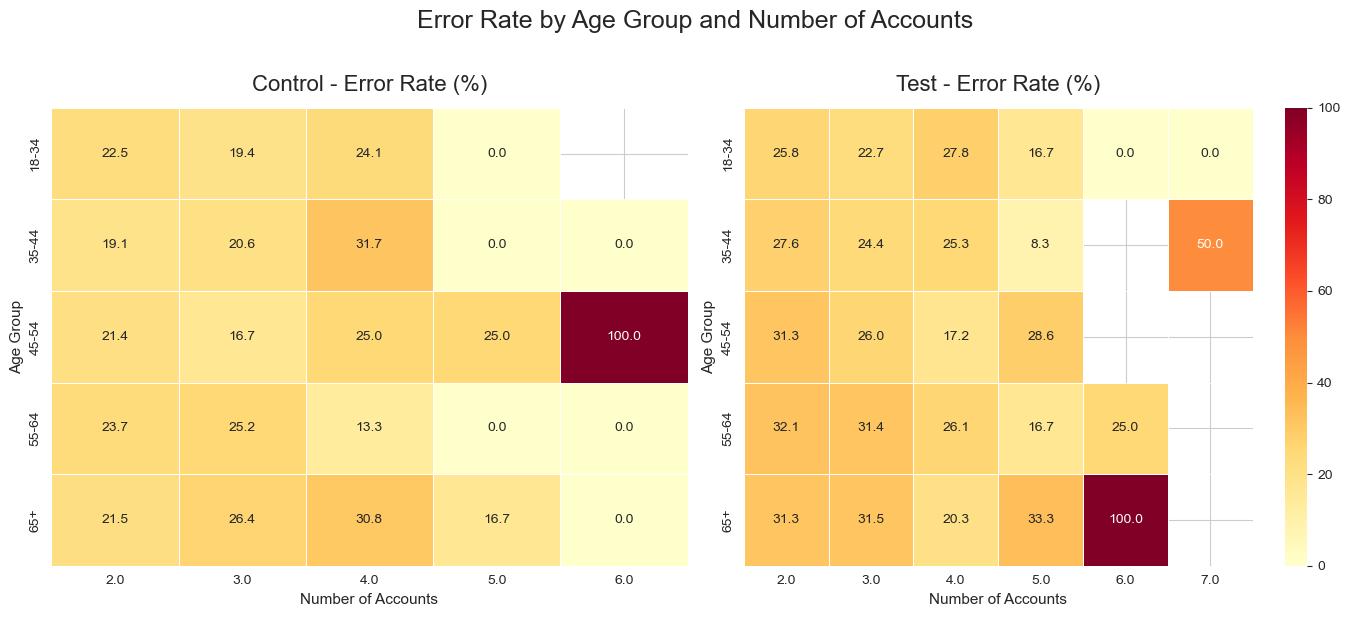

In [669]:

# -----------------------------------
# Create figure
# -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="white")

variations = ["Control", "Test"]

for ax, var in zip(axes, variations):
    temp = error_accounts[error_accounts["variation"] == var]

    pivot = pd.pivot_table(
        temp,
        index="age_group",
        columns="num_accts",
        values="had_error",
        aggfunc="mean"
    ) * 100

    pivot = pivot.round(1)

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.5,
        cbar=ax == axes[1],
        ax=ax
    )

    ax.set_title(f"{var} - Error Rate (%)", fontsize=16, pad=12)
    ax.set_xlabel("Number of Accounts", fontsize=11)
    ax.set_ylabel("Age Group", fontsize=11)

plt.suptitle(
    "Error Rate by Age Group and Number of Accounts",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

/var/folders/n4/6rmpk97n5xb3v5g_m1d_4dk40000gn/T/ipykernel_91655/3135686056.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  client_level.groupby(["age_group", "variation"])[


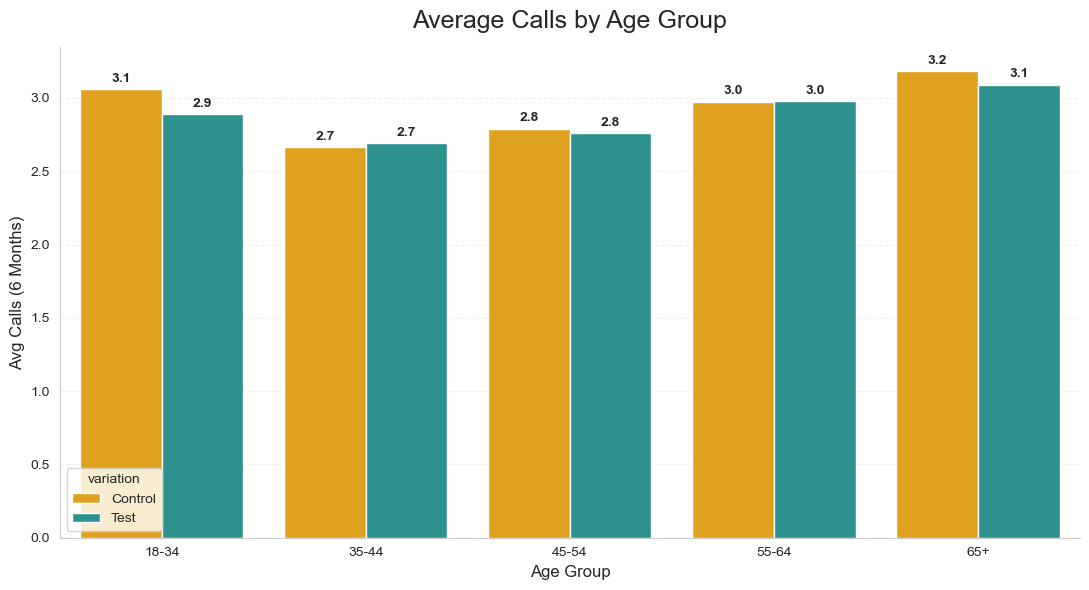

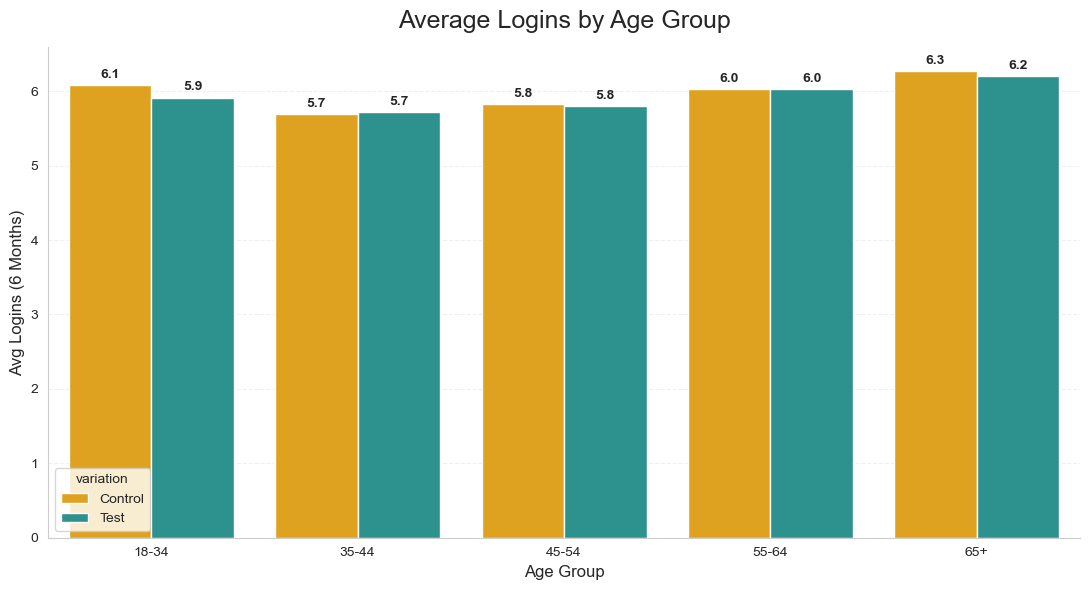

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# Aggregate by age_group + variation
# -----------------------------------
age_summary = (
    client_level.groupby(["age_group", "variation"])[
        ["calls_6_mnth", "logons_6_mnth"]
    ]
    .mean()
    .reset_index()
)

# Order age groups
age_order = ["18-34", "35-44", "45-54", "55-64", "65+"]

age_summary["age_group"] = pd.Categorical(
    age_summary["age_group"],
    categories=age_order,
    ordered=True
)

# Notebook colors
palette = {
    "Control": "#ffad00",
    "Test": "#1ca39c"
}

# -------------------------------------------------
# Function to add labels
# -------------------------------------------------
def add_labels(ax):
    for container in ax.containers:
        labels = [f"{v:.1f}" for v in container.datavalues]
        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=10,
            fontweight="bold"
        )

# -----------------------------------
# Chart 1: Calls
# -----------------------------------
plt.figure(figsize=(11,6), facecolor="white")

ax = sns.barplot(
    data=age_summary,
    x="age_group",
    y="calls_6_mnth",
    hue="variation",
    palette=palette
)

add_labels(ax)

ax.set_title("Average Calls by Age Group", fontsize=18, pad=14)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Avg Calls (6 Months)", fontsize=12)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

sns.despine()
plt.tight_layout()
plt.show()

# -----------------------------------
# Chart 2: Logins
# -----------------------------------
plt.figure(figsize=(11,6), facecolor="white")

ax = sns.barplot(
    data=age_summary,
    x="age_group",
    y="logons_6_mnth",
    hue="variation",
    palette=palette
)

add_labels(ax)

ax.set_title("Average Logins by Age Group", fontsize=18, pad=14)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Avg Logins (6 Months)", fontsize=12)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

sns.despine()
plt.tight_layout()
plt.show()